In [6]:
import joblib


**Load data**

In [7]:
df = joblib.load("processed_data.joblib")

In [8]:
X_train = df["X_train"]
y_train = df["y_train"]
X_test = df["X_test"]
y_test = df["y_test"]


**KNN**

In [20]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score
f1_train_scores= []
f1_test_scores= []
k_val = []
for k in range(2,151):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_train_pred = knn.predict(X_train)
    y_test_pred = knn.predict(X_test)
    f1_train_scores.append(f1_score(y_train, y_train_pred))
    f1_test_scores.append(f1_score(y_test, y_test_pred))
    k_val.append(k)
    k+=1



**Visualize**

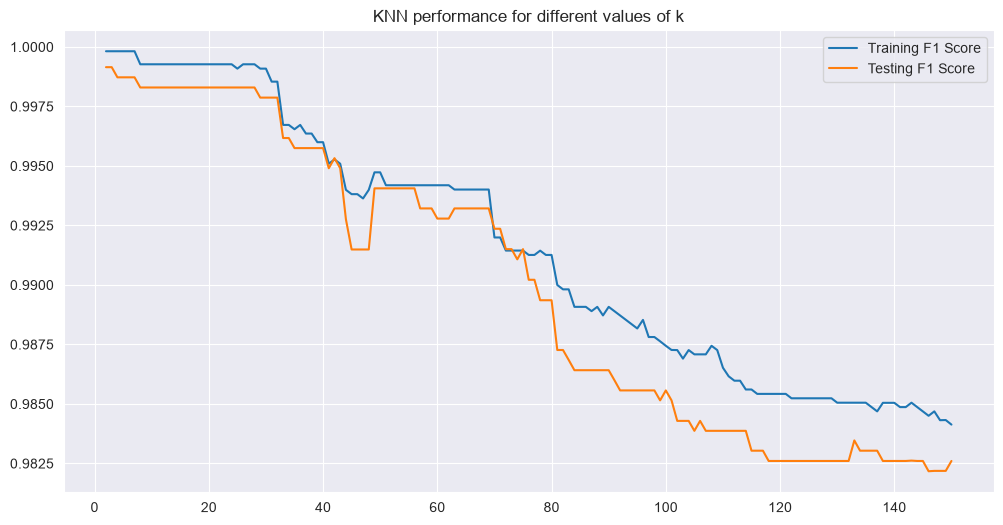

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize = (12,6))

sns.lineplot(x=k_val, y=f1_train_scores, label="Training F1 Score")
sns.lineplot(x=k_val, y=f1_test_scores, label="Testing F1 Score")

plt.xlabel = "K values"
plt.ylabel = "f1_score"
plt.title("KNN performance for different values of k")
plt.legend()
plt.grid(True)
plt.show()


**Finding K best value**

In [28]:
best_index = f1_test_scores.index(max(f1_test_scores))

best_k = k_val[best_index]
best_test_f1 = f1_test_scores[best_index]
best_train_f1 = f1_train_scores[best_index]

print("Best K:", best_k)
print("Training F1-score:", best_train_f1)
print("Testing F1-score:", best_test_f1)

Best K: 2
Training F1-score: 0.9998175515416895
Testing F1-score: 0.9991482112436116


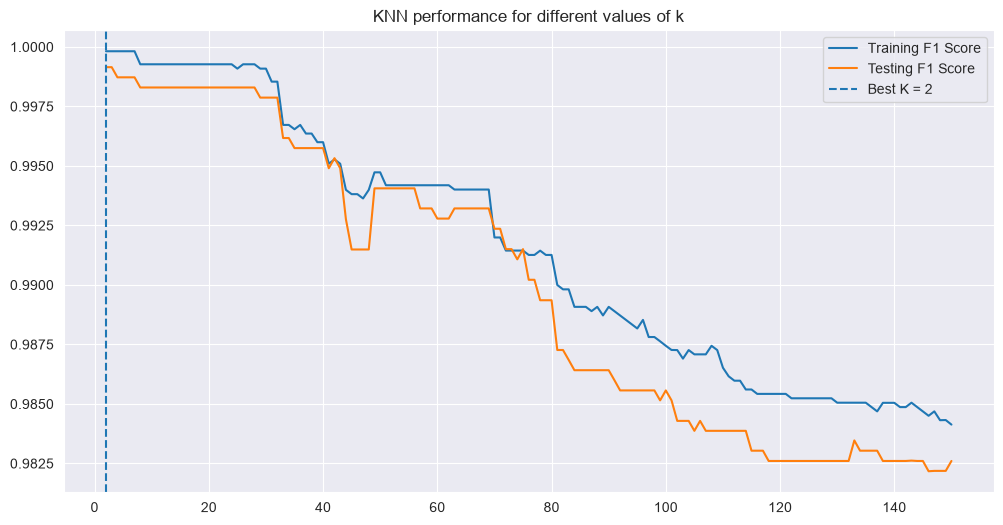

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize = (12,6))

sns.lineplot(x=k_val, y=f1_train_scores, label="Training F1 Score")
sns.lineplot(x=k_val, y=f1_test_scores, label="Testing F1 Score")
plt.axvline(
    best_k,
    linestyle="--",
    label=f"Best K = {best_k}"
)

plt.xlabel = "K values"
plt.ylabel = "f1_score"
plt.title("KNN performance for different values of k")
plt.legend()
plt.grid(True)
plt.show()
